In [1]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import numpy as np
from pydicom import dcmread
import os
import cv2
import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential 
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
from keras import optimizers
from keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import torch
from tensorflow.keras.layers import Dense, BatchNormalization
import tensorflow as tf

In [2]:
#套件
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
from pydicom import dcmread
import os
import cv2
import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential 
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
import matplotlib.pyplot as plt
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import concatenate
from keras import optimizers

from keras.wrappers.scikit_learn import KerasClassifier

from tensorflow.keras.applications import ResNet50
import gc
from tensorflow.keras import regularizers
from keras import callbacks
from keras import backend as K
from sklearn.model_selection import KFold
import glob
import pickle

from keras.layers import Dense, Input, Conv2D, Flatten, MaxPooling2D, Activation, Dropout, Average
from keras.models import Model
from keras.models import load_model
from tensorflow.keras.callbacks import LearningRateScheduler

In [3]:
from tensorflow.python.client import device_lib #確認GPU是否有運作
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 15445681437630150974
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 1736599143
locality {
  bus_id: 1
  links {
  }
}
incarnation: 8867817847292490420
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6"
]


In [4]:
df = pd.read_csv('train2.csv') # create df

In [5]:
x = df['ID'].values #重新設定檔名

In [6]:
L = []
for i in range(len(x)):
    if len(str(x[i])) < 7:
        t = '0'* (7- len(str(x[i])))
        file = t + str(x[i])
    else:
        file = str(x[i])
    L.append(file)

In [7]:
df['ID'] = L # reset ID to make it consistency
df

,ID,Disease
0,1067739,1
1,1038067,0
2,0422411,1
3,0091553,1
4,1047213,1
...,...,...
155,0651657,1
156,0436524,1
157,0148593,1
158,1057213,1


# load training data

In [8]:
#load T1 data
T1 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T1' #set path
    os.chdir(path) #to filepath
    x = os.listdir() 
    data = [0]*len(x) #create array to put image，每個病患都不同數量
    for j in x:
        ds = dcmread(j) #read dicom
        WC = ds.WindowCenter # WC = (最高可視 + 最低) / 2
        WW = ds.WindowWidth # WW = H-L
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2 
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array) #read image
        arr = arr[106:406,106:406] #crop image to 300*300 。512*512太大張了，gpu難以負荷。(OOM problem)
        # adj img_val
        arr[arr > H] = H 
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) # normalized to a range of [0,255]
        data[int(ds.InstanceNumber)-1] = arr #按照順序排放image
    data = np.array(data) 
    x_np = torch.from_numpy(data) # to tensor
    x_np = x_np[None, None, :] # trilinear要求五維，因此增加維度
    x_np = torch.nn.functional.interpolate(x_np, size= [22,300,300], scale_factor=None, mode='trilinear') #內插法，depth = 22 
    x_np = torch.reshape(x_np, (22,300,300))
    x_np = x_np.numpy() #back to np
    T1.append(x_np)

In [9]:
T1 = np.array(T1) # (Number,Depth,Hight,Width)
T1.shape

(160, 22, 300, 300)

In [10]:
T2 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T2'
    os.chdir(path) #到指定資料夾
    y = os.listdir()
    data = [0]*len(y)
    for j in y:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    y_np = torch.from_numpy(data)
    y_np = y_np[None, None, :]
    y_np = torch.nn.functional.interpolate(y_np, size= [22,300,300], scale_factor=None, mode='trilinear')
    y_np = torch.reshape(y_np, (22,300,300))
    y_np = y_np.numpy()
    T2.append(y_np)

In [11]:
os.chdir('C:\\Users\\James') #到指定資料夾

In [12]:
T2 = np.array(T2) #get T2 data
T2.shape

(160, 22, 300, 300)

In [13]:
#set 3 channel (T1,T2,avg)
X_train = []
for i in range(len(T1)):
    x = T1[i]
    y = T2[i]
    z = (T1[i]+T2[i])/2
    i1 = np.expand_dims(x,axis=3)#channel1 =T1
    i2 = np.expand_dims(y,axis=3)#channel2 =T2
    i3 = np.expand_dims(z,axis=3)#channel3 =avg
    image = np.concatenate((i1,i2,i3),axis=-1) #3channel   
    image = image / 255 #歸一化
    X_train.append(image)

In [14]:
X_train = np.array(X_train)
X_train.shape  #(N,D,H,W,Channel)，3d image with 3 channel

(160, 22, 300, 300, 3)

In [15]:
y_train = np.array(df.Disease) #get label

In [16]:
y_train.shape

(160,)

In [17]:
X_train_all = np.reshape(X_train,(3520,300,300,3)) # singel slice reshape

In [18]:
X_train_all.shape # 3520張 2D image

(3520, 300, 300, 3)

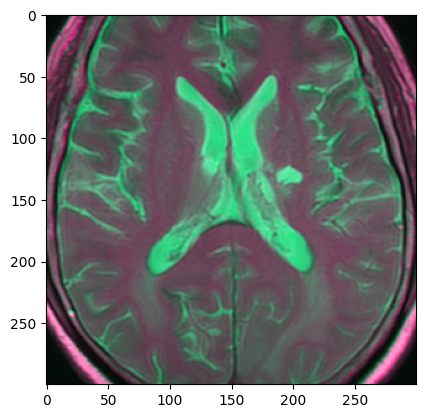

In [19]:
import matplotlib.pyplot as plt
plt.imshow(X_train_all[12])

In [20]:
#reshape y_train
y_train_all =[]
for i in y_train:
    val = [i]*22
    y_train_all.append(val)
y_train_all = np.array(y_train_all).flatten()

In [21]:
y_train_all.shape

(3520,)

In [22]:
#data augmentation !! return a batch for training 
def data_aug(X_train,X_test,y_train,y_test,train_batch_size,test_batch_size):
    train_datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest')
    test_datagen = ImageDataGenerator() # no operation in test 
    train_batch = train_datagen.flow(X_train,y_train,batch_size=train_batch_size)
    test_batch = test_datagen.flow(X_test,y_test,batch_size=test_batch_size)
    return (train_batch,test_batch)

In [23]:
#定義 vgg16 model
def vgg16():
    base_model = VGG16(weights='imagenet', include_top=False,input_shape=(300, 300, 3))#pre_train vgg16 。自行定義 FC layer
    x = base_model.output # x為經過vgg16 預設5block之output 
    x = Flatten()(x) #flatten 
    x = Dense(128, activation="relu", kernel_regularizer=regularizers.L2(0.01))(x) # activation with l2 regularizer
    x = BatchNormalization()(x)
    x = Dense(64, activation="relu", kernel_regularizer=regularizers.L2(0.01))(x)# activation with l2 regularizer
    x = BatchNormalization(name = 'bn_fc01')(x) # batch normalization
    x = Dense(1, activation="sigmoid")(x) # Fc = sigmoid (binary) 
    model = Model(inputs=base_model.input, outputs=x) #set model architecture

    # VGG16 原有的層均不重新訓練
    for layer in base_model.layers:
        layer.trainable = False
    return model

In [24]:
# vgg16 summary
model = vgg16()
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 300, 300, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 300, 300, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 300, 300, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 150, 150, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 150, 150, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 150, 150, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 75, 75, 128)       0     

In [25]:
# lr scheduler 每過10個epoch，降低lr。lr從大至小，學習步伐越來越小，直至收斂。減少震盪
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [26]:
callback2 = LearningRateScheduler(scheduler)

In [27]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=1e-4, decay=0.0) #優化採用adam ，起始直因batch size小。取小一點。

In [28]:
from keras.callbacks import EarlyStopping

# early stop : 15個epoch val acc沒有增加，停止訓練
callback = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0,
    patience=15,
    verbose=0,
    mode="max")

In [29]:
gc.collect() # 
keras.backend.clear_session() #clear session

In [30]:
from sklearn.model_selection import train_test_split
    
#split train and val data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.3, random_state=66)
    
    # CREATE NEW MODEL
model = vgg16()
    
    # CREATE NEW model compile
model.compile(loss='binary_crossentropy',
            optimizer=optimizer ,
            metrics=['accuracy'])
    
    
train_batch, val_batch = data_aug(X_train,X_val,y_train,y_val, 16 , 8)
    
epochs = 100
history = model.fit_generator(train_batch, validation_data=val_batch, epochs=epochs, validation_steps= X_val.shape[0] // 8, 
                        steps_per_epoch= X_train.shape[0] // 16, callbacks=[callback,callback2], verbose=2)



C:\Users\James\anaconda3\envs\tf_2.6_py_3.7\lib\site-packages\keras\engine\training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/100
154/154 - 108s - loss: 3.3110 - accuracy: 0.6080 - val_loss: 2.8980 - val_accuracy: 0.6373
Epoch 2/100
154/154 - 58s - loss: 2.7060 - accuracy: 0.6733 - val_loss: 2.5065 - val_accuracy: 0.7008
Epoch 3/100
154/154 - 57s - loss: 2.3921 - accuracy: 0.6859 - val_loss: 2.2937 - val_accuracy: 0.6856
Epoch 4/100
154/154 - 56s - loss: 2.1400 - accuracy: 0.7005 - val_loss: 2.0387 - val_accuracy: 0.7216
Epoch 5/100
154/154 - 58s - loss: 1.9480 - accuracy: 0.7261 - val_loss: 1.7863 - val_accuracy: 0.7699
Epoch 6/100
154/154 - 56s - loss: 1.7880 - accuracy: 0.7317 - val_loss: 1.7342 - val_accuracy: 0.7282
Epoch 7/100
154/154 - 56s - loss: 1.6546 - accuracy: 0.7220 - val_loss: 1.6198 - val_accuracy: 0.7292
Epoch 8/100
154/154 - 56s - loss: 1.5400 - accuracy: 0.7240 - val_loss: 1.4098 - val_accuracy: 0.7822
Epoch 9/100
154/154 - 56s - loss: 1.4164 - accuracy: 0.7524 - val_loss: 1.4284 - val_accuracy: 0.7367
Epoch 10/100
154/154 - 57s - loss: 1.3527 - accuracy: 0.7415 - val_loss: 1.2683 -

In [31]:
#tf.saved_model.save(model, 's'+ str(Fold)) 
model.save('slice')
    
scores = model.evaluate(X_val, y_val, batch_size=1, verbose=2) #downsample to avoid oom
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))
    
gc.collect() # 
keras.backend.clear_session() #clear session


INFO:tensorflow:Assets written to: slice\assets
1056/1056 - 16s - loss: 0.7247 - accuracy: 0.8400
accuracy: 84.00%


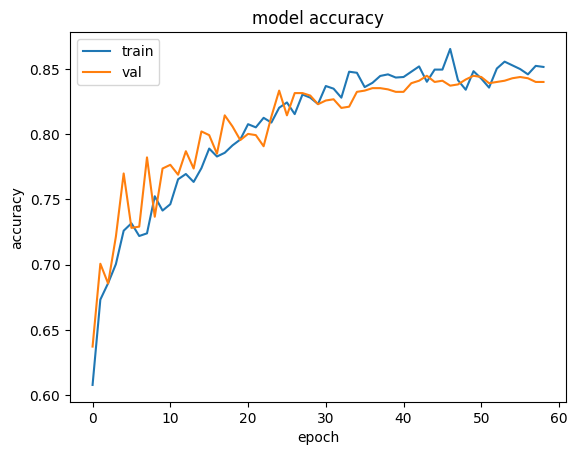

In [32]:
#plot history
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
    
    

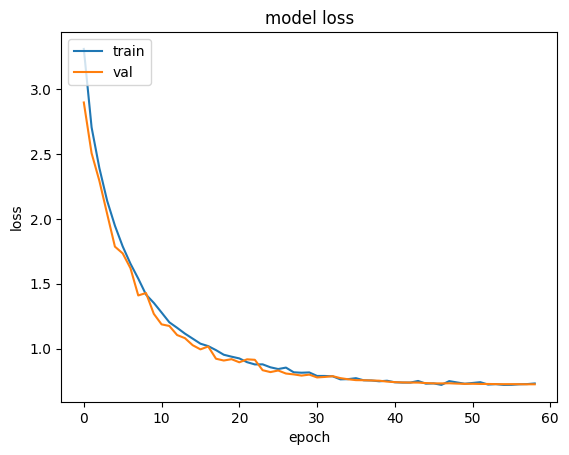

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [34]:
# val accuracy收斂在0.84左右。loss 0.7左右

In [36]:
#load test
os.chdir('C:\\Users\\James')
df = pd.read_csv('test2.csv')

In [37]:
x = df['ID'].values

In [38]:
L = []
for i in range(len(x)):
    if len(str(x[i])) < 7:
        t = '0'* (7- len(str(x[i])))
        file = t + str(x[i])
    else:
        file = str(x[i])
    L.append(file)

In [39]:
df['ID'] = L
df

,ID,Disease 0,Disease 1,Disease
0,1035303,NaN,NaN,NaN
1,1032110,NaN,NaN,NaN
2,0003158,NaN,NaN,NaN
3,0759590,NaN,NaN,NaN
4,0903423,NaN,NaN,NaN
5,0629424,NaN,NaN,NaN
6,0984633,NaN,NaN,NaN
7,0908999,NaN,NaN,NaN
8,0011338,NaN,NaN,NaN
9,1070273,NaN,NaN,NaN


In [40]:
T1 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T1'
    os.chdir(path) #到指定資料夾
    x = os.listdir()
    data = [0]*len(x)
    for j in x:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    x_np = torch.from_numpy(data)
    x_np = x_np[None, None, :]
    x_np = torch.nn.functional.interpolate(x_np, size= [22,300,300], scale_factor=None, mode='trilinear')
    x_np = torch.reshape(x_np, (22,300,300))
    x_np = x_np.numpy()
    T1.append(x_np)

In [41]:
T2 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T2'
    os.chdir(path) #到指定資料夾
    y = os.listdir()
    data = [0]*len(y)
    for j in y:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    y_np = torch.from_numpy(data)
    y_np = y_np[None, None, :]
    y_np = torch.nn.functional.interpolate(y_np, size= [22,300,300], scale_factor=None, mode='trilinear')
    y_np = torch.reshape(y_np, (22,300,300))
    y_np = y_np.numpy()
    T2.append(y_np)

In [42]:
T2 = np.array(T2)

In [43]:
X_test = []
for i in range(len(T1)):
    x = T1[i]
    y = T2[i]
    z = (T1[i]+T2[i])/2
    i1 = np.expand_dims(x,axis=3)
    i2 = np.expand_dims(y,axis=3)
    i3 = np.expand_dims(z,axis=3)
    image = np.concatenate((i1,i2,i3),axis=-1)
    image = image / 255
    X_test.append(image)

In [44]:
X_test = np.array(X_test)
X_test.shape  #(N,D,H,W,Channel)

(40, 22, 300, 300, 3)

In [45]:
X_test = np.reshape(X_test,(880,300,300,3))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


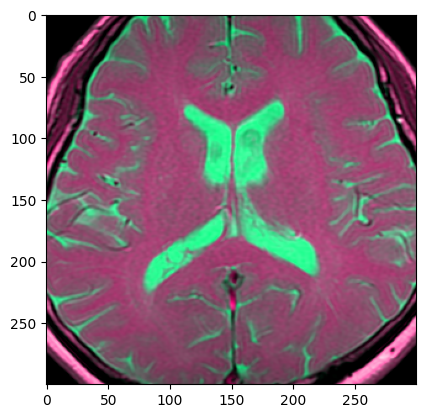

In [46]:
import matplotlib.pyplot as plt
plt.imshow(X_test[12])

In [47]:
gc.collect()
K.clear_session()
proba = model.predict(X_test[:440],batch_size= 1) #前440張，分兩批預測

In [48]:
proba2 = model.predict(X_test[440:],batch_size= 1)

In [49]:
Disease_1 = proba.flatten()

In [50]:
Disease_1_2 = proba2.flatten()

In [51]:
x = []
for i in range(880):
    if i < 440:
        x.append(Disease_1[i])
    else:
        x.append(Disease_1_2[440-i])
        
x = np.array(x) 

In [52]:
x.shape

(880,)

In [53]:
Disease_1 = []
for i in range(40):
    Sum = 0
    for j in range(22):
        Sum += x[i]
    Avg = Sum / 22
    Disease_1.append(Avg)

In [54]:
Disease_1 = np.array(Disease_1)

In [55]:
Disease_0 = np.ones(40) - Disease_1

In [56]:
Disease = []
for i in Disease_1:
    if i > 0.5:
        Disease.append(1)
    else:
        Disease.append(0)
Disease = np.array(Disease)

In [57]:
df.columns = ['ID', 'Disease_0', 'Disease_1', 'Disease']

In [58]:
df['Disease_0'] = Disease_0
df['Disease_1'] = Disease_1
df['Disease'] = Disease


In [59]:
df

,ID,Disease_0,Disease_1,Disease
0,1035303,0.025771,0.974229,1
1,1032110,0.097986,0.902014,1
2,0003158,0.078101,0.921899,1
3,0759590,0.148248,0.851752,1
4,0903423,0.119021,0.880979,1
5,0629424,0.582247,0.417753,0
6,0984633,0.635373,0.364627,0
7,0908999,0.366311,0.633689,1
8,0011338,0.848097,0.151903,0
9,1070273,0.484983,0.515017,1


In [61]:
os.chdir('C:\\Users\\James')
df.to_csv("single.csv")